In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

In [2]:
m = .2
a = 1
dimx = 16
dimt = 32
beta = 10
totalSteps = 50000

In [3]:
with open('50kSteps.pkl', 'rb') as f:
    temp = pickle.load(f)

In [8]:
bIn = 500
skp = 500

gamma = np.array([[1j,0],[0,-1j]])
correlSigma3 = sim.correlation.GEVPStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,smearN1=4,kappa1=1.2,ti=0)
correlSigma3Orig = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma)

100%|██████████| 99/99 [00:04<00:00, 20.60it/s]


In [9]:
effectiveMassSigma3 = sim.analysis.effectiveMassProp(correlSigma3,coshExpr=True)
effectiveMassSigma3Orig = sim.analysis.effectiveMassProp(correlSigma3Orig,coshExpr=True)

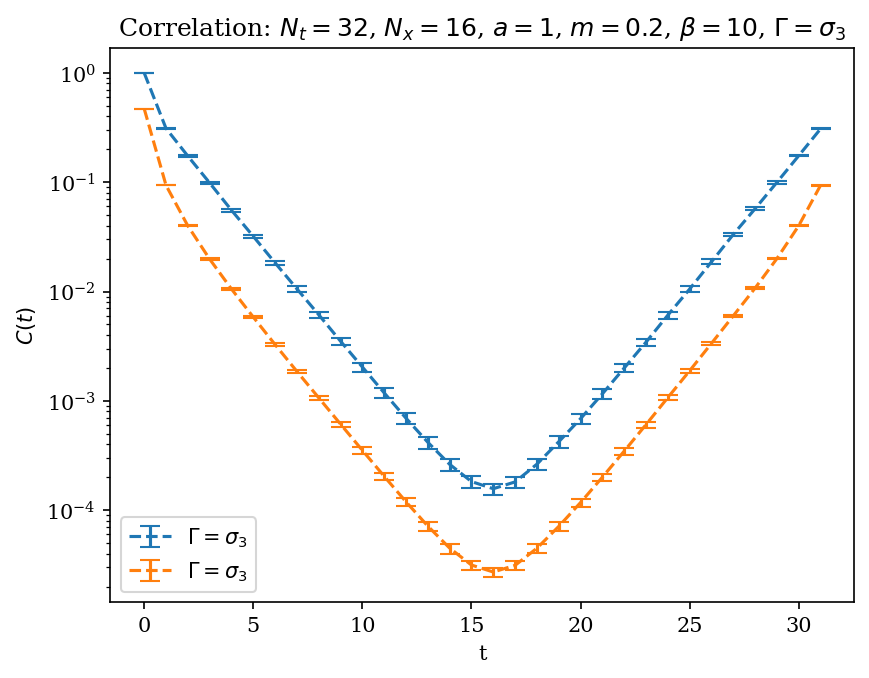

In [10]:
plt.figure(dpi=150)

plt.errorbar(x=np.arange(len(correlSigma3[0])),y=correlSigma3[0],yerr=correlSigma3[1],ls="--",capsize=5,label=r"$\Gamma=\sigma_3$")
plt.errorbar(x=np.arange(len(correlSigma3Orig[0])),y=correlSigma3Orig[0],yerr=correlSigma3Orig[1],ls="--",capsize=5,label=r"$\Gamma=\sigma_3$")

plt.semilogy()
plt.xlabel("t")
plt.ylabel(r"$C(t)$")
plt.title(rf"Correlation: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")
plt.legend()

(0.0, 1.0)

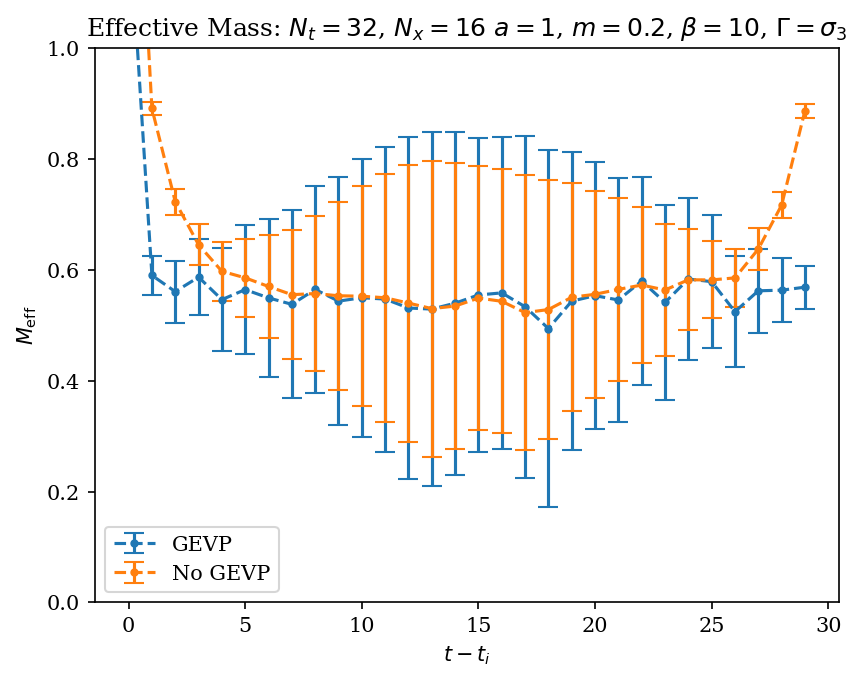

In [11]:
plt.figure(dpi=150)

plt.errorbar(x=np.arange(len(effectiveMassSigma3[0])),y=(effectiveMassSigma3[0]),yerr=effectiveMassSigma3[1],ls="--",marker=".",capsize=5,label=r"GEVP")
plt.errorbar(x=np.arange(len(effectiveMassSigma3Orig[0])),y=(effectiveMassSigma3Orig[0]),yerr=effectiveMassSigma3Orig[1],ls="--",marker=".",capsize=5,label=r"No GEVP")
plt.xlabel(r"$t-t_i$")
plt.xlabel(r"$t-t_i$")
plt.ylabel(r"$M_{\text{eff}}$")
plt.title(rf"Effective Mass: $N_t = {dimt}$, $N_x={dimx}$ $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")
plt.legend()
plt.ylim([0,1])